### PySpark Otomoto Demo 

Źródło danych: https://www.kaggle.com/datasets/szymoncyperski/car-sales-offers-from-otomotopl-2023 


In [1]:
import os
os.environ["JAVA_HOME"] = "/opt/homebrew/opt/openjdk@17/libexec/openjdk.jdk/Contents/Home"

from pyspark.sql import SparkSession
from pyspark.sql import functions as F
import matplotlib.pyplot as plt

**Teoria:** Powyżej importujemy niezbędne biblioteki. `SparkSession` to główny punkt wejścia do funkcjonalności DataFrame i SQL w Sparku (od wersji 2.0). Moduł `functions` dostarcza wbudowane funkcje operujące na kolumnach, a `matplotlib.pyplot` posłuży nam do późniejszej wizualizacji danych.


In [2]:
if "JAVA_HOME" in os.environ:
    del os.environ["JAVA_HOME"]

spark = SparkSession.builder \
    .appName("Otomoto Demo") \
    .getOrCreate()

**Teoria:** Tworzymy sesję Sparka. `builder` używa wzorca projektowego Builder do skonfigurowania sesji. `getOrCreate()` tworzy nową sesję lub pobiera istniejącą, co jest bezpieczne przy wielokrotnym uruchamianiu notatnika.


In [3]:
df = spark.read.option("header", True) \
    .option("delimiter", ";") \
    .option("inferSchema", False) \
    .csv("otomoto_offers_eng_23-04-2023.csv")


**Teoria:** Wczytywanie danych. Spark używa leniwego ewaluowania (lazy evaluation) - dane nie są fizycznie wczytywane w tym momencie, tworzony jest tylko plan wykonania (DAG). Ustawiamy `header=True` ponieważ nasz plik CSV ma nagłówki, oraz określamy separator jako średnik `;`.


In [4]:
df.show()

+----------+-------------------+--------------------+------+--------+-----------------+------------------------+--------------------+---------------+--------+---------------------------+-------------+-------------+---------------+---------------+----------+-------------------+--------------+------+------------+-------------+---------------+---------------+---------+----------+---------------------+-----+--------------------+------------------------+----------+-----+---------------------------+------------+-----------+--------------------------+--------------------------+--------------+-------------+----------------------+----------------------------------+----------------------------+----------------------+---------------------+--------------+------------------------------------+-------------------+----------------+--------------+---------------+------------+----+-------------------+-------------+----------------+------------------+------------------+------------------+----------------

**Teoria:** `show()` to akcja (action), która uruchamia wykonanie obliczeń w Sparku. Dopiero teraz plik jest odczytywany, a wynik prezentowany na ekranie.


In [5]:
df.filter(F.col("vehicle_brand") == "Volvo").show()

+----------+-------------------+--------------------+------+--------+-----------------+------------------------+--------------------+---------------+--------+---------------------------+-------------+-------------+-------------+---------------+----------+-------------------+---------+------+------------+-------------+---------------+---------------+--------+----------+---------------------+-----+--------------------+------------------------+----------+-----+---------------------------+------------+-----------+--------------------------+--------------------------+--------------+-------------+----------------------+----------------------------------+----------------------------+----------------------+---------------------+--------------+------------------------------------+-------------------+----------------+--------------+---------------+------------+----+-------------------+-------------+----------------+------------------+------------------+------------------+-----------------+------

In [6]:
df = df.withColumn("price_num",
                   F.regexp_replace(F.col("price"), r"[^\d]", "").cast("double"))

df = df.withColumn("mileage_km",
                   F.regexp_replace(F.col("mileage"), r"[^\d]", "").cast("integer"))

df = df.withColumn("production_year_int",
                   F.regexp_replace(F.col("production_year"), r"[^\d]", "").cast("integer"))

df = df.withColumn("engine_cc",
                   F.regexp_replace(F.col("engine_displacement"), r"[^\d]", "").cast("integer"))

df = df.withColumn("power_hp",
                   F.regexp_replace(F.col("power"), r"[^\d]", "").cast("integer"))

df = df.withColumn("fuel_clean",
                   F.lower(F.trim(F.col("fuel_type"))))

In [7]:
df.select("vehicle_brand", "vehicle_model", "price_num", "mileage_km",
          "production_year_int", "engine_cc", "power_hp", "fuel_clean") \
  .show(10, truncate=False)

+-------------+-------------+---------+----------+-------------------+---------+--------+--------------+
|vehicle_brand|vehicle_model|price_num|mileage_km|production_year_int|engine_cc|power_hp|fuel_clean    |
+-------------+-------------+---------+----------+-------------------+---------+--------+--------------+
|Volvo        |V70          |23200.0  |304000    |2010               |15603    |109     |diesel        |
|Honda        |Accord       |16800.0  |236000    |2005               |19983    |155     |gasoline      |
|Mercedes-Benz|Klasa X      |249900.0 |73000     |2019               |29873    |258     |diesel        |
|Toyota       |Avensis      |16499.0  |220000    |2005               |17943    |129     |gasoline      |
|Ford         |C-MAX        |29900.0  |179058    |2012               |19973    |140     |diesel        |
|Peugeot      |208          |80900.0  |1         |2023               |11993    |75      |gasoline      |
|Kia          |Sportage     |74770.0  |100420    |2018 

**Teoria:** `select()` to transformacja, która działa jak w SQL - pozwala wybrać podzbiór kolumn. Zmniejsza to ilość przetwarzanych danych w dalszych krokach.


In [8]:
avg_brand = df.groupBy("vehicle_brand") \
              .agg(F.round(F.avg("price_num"), 2).alias("avg_price")) \
              .orderBy(F.col("avg_price").desc())

print("Średnia cena per marka")
avg_brand.show(20, truncate=False)

Średnia cena per marka
+-------------+----------+
|vehicle_brand|avg_price |
+-------------+----------+
|Lamborghini  |1281601.59|
|Ferrari      |1015648.41|
|McLaren      |866462.12 |
|Rolls-Royce  |762649.96 |
|Bentley      |657051.57 |
|Maybach      |575529.83 |
|Aston Martin |530891.29 |
|KTM          |389000.0  |
|Porsche      |363902.5  |
|Alpine       |352555.5  |
|RAM          |348905.66 |
|Geely        |346903.0  |
|BMW-ALPINA   |333006.94 |
|LEVC         |305776.0  |
|Skywell      |274743.33 |
|Maxus        |255052.59 |
|Tesla        |232544.92 |
|Caterham     |227550.0  |
|Land Rover   |200495.64 |
|Maserati     |197591.6  |
+-------------+----------+
only showing top 20 rows


In [9]:
fuel_count = df.groupBy("fuel_clean").count()
print("Liczba ogłoszeń wg rodzaju paliwa")
fuel_count.show()

Liczba ogłoszeń wg rodzaju paliwa
+--------------+------+
|    fuel_clean| count|
+--------------+------+
|      gasoline|101165|
|        diesel| 88624|
|gasoline + lpg|  7419|
|        hybrid|  7527|
|gasoline + cng|    96|
|      electric|  3373|
|      hydrogen|     1|
+--------------+------+



In [10]:
df.createOrReplaceTempView("cars")

In [11]:
# SQL: zależność mocy i pojemności od ceny
spark.sql("""
    SELECT vehicle_brand,
           ROUND(AVG(power_hp), 1) AS avg_power,
           ROUND(AVG(engine_cc), 1) AS avg_cc,
           ROUND(AVG(price_num), 1) AS avg_price
    FROM cars
    GROUP BY vehicle_brand
    ORDER BY avg_power DESC
""").show()

+-------------+---------+-------+---------+
|vehicle_brand|avg_power| avg_cc|avg_price|
+-------------+---------+-------+---------+
|      McLaren|    652.5|38811.5| 866462.1|
|  Lamborghini|    637.8|51767.4|1281601.6|
|      Ferrari|    632.9|46168.3|1015648.4|
|      Bentley|    550.8|54644.1| 657051.6|
|      Maybach|    541.0|53499.7| 575529.8|
| Aston Martin|    528.1|48457.7| 530891.3|
|   BMW-ALPINA|    516.0|40259.4| 333006.9|
|        Tesla|    486.4| 6023.0| 232544.9|
|  Rolls-Royce|    479.7|65997.4| 762650.0|
|          RAM|    413.2|55898.3| 348905.7|
|     Polestar|    408.0|   NULL| 146750.0|
|     Maserati|    397.7|31911.3| 197591.6|
|      Porsche|    376.8|33072.8| 363902.5|
|          KTM|    362.0|19843.0| 389000.0|
|        Dodge|    341.5|46547.9| 142202.8|
|      Genesis|    336.3|31915.5| 108725.0|
|     Cadillac|    309.1|47372.8| 140824.6|
|          GMC|    290.3|50369.8| 135253.3|
|     Plymouth|    287.5|50298.0| 125230.0|
|       Hummer|    278.3|49413.6

In [12]:
df.groupBy("production_year_int") \
  .count() \
  .orderBy(F.col("production_year_int").desc()) \
  .show()

+-------------------+-----+
|production_year_int|count|
+-------------------+-----+
|               2023|12987|
|               2022|13680|
|               2021| 7729|
|               2020| 7787|
|               2019|13978|
|               2018|15096|
|               2017|13952|
|               2016|11755|
|               2015|10640|
|               2014| 9988|
|               2013| 9341|
|               2012| 9664|
|               2011|10108|
|               2010| 9115|
|               2009| 9040|
|               2008| 8846|
|               2007| 7816|
|               2006| 6320|
|               2005| 5121|
|               2004| 3647|
+-------------------+-----+
only showing top 20 rows


In [13]:
# Średnia cena i przebieg per marka i model
df.groupBy("vehicle_brand", "vehicle_model") \
  .agg(
      F.round(F.avg("price_num"), 2).alias("avg_price"),
      F.round(F.avg("mileage_km"), 2).alias("avg_mileage")
  ) \
  .orderBy(F.col("avg_price").desc()) \
  .show(20, truncate=False)

+-------------+-------------+----------+-----------+
|vehicle_brand|vehicle_model|avg_price |avg_mileage|
+-------------+-------------+----------+-----------+
|Ferrari      |812 GTS      |2750000.0 |2000.0     |
|Mercedes-Benz|SLR          |2340000.0 |2380.0     |
|Ferrari      |SF90 Stradale|2293626.0 |1855.75    |
|Rolls-Royce  |Dawn         |1999999.0 |4300.0     |
|Lamborghini  |Aventador    |1822661.67|14467.5    |
|Ferrari      |812 Superfast|1670200.0 |16414.0    |
|Lamborghini  |Murcielago   |1550000.0 |46950.0    |
|McLaren      |Artura       |1499000.0 |2100.0     |
|McLaren      |675Lt        |1290000.0 |18500.0    |
|McLaren      |600lt-coupe  |1289000.0 |8500.0     |
|Lamborghini  |Huracan      |1258737.0 |25671.46   |
|Rolls-Royce  |Phantom      |1225000.0 |22000.0    |
|Rolls-Royce  |Ghost        |1206316.67|39451.67   |
|Bentley      |Bentayga     |1200222.11|34022.72   |
|Lamborghini  |Diablo       |1199900.0 |32164.0    |
|Rolls-Royce  |Wraith       |1183000.0 |54333.

In [14]:
# zależność ceny od przebiegu 
price_mileage = df.select("price_num", "mileage_km") \
                  .where((F.col("price_num").isNotNull()) & (F.col("mileage_km").isNotNull()))

Wizualizacja scatter zapisana jako scatter_price_mileage.png


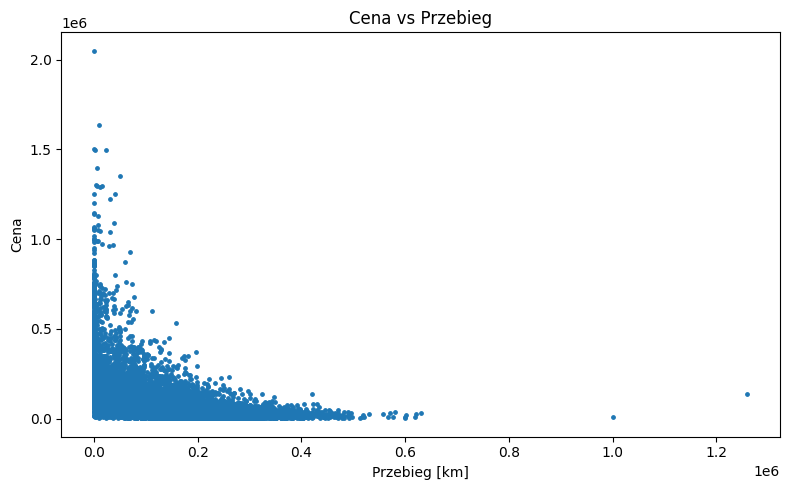

In [15]:
pdf_scatter = price_mileage.sample(fraction=0.1, seed=42).toPandas()

plt.figure(figsize=(8,5))
plt.scatter(pdf_scatter["mileage_km"], pdf_scatter["price_num"], s=6)
plt.title("Cena vs Przebieg")
plt.xlabel("Przebieg [km]")
plt.ylabel("Cena")
plt.tight_layout()
plt.savefig("scatter_price_mileage.png")

print("Wizualizacja scatter zapisana jako scatter_price_mileage.png")

**Teoria:** `toPandas()` to akcja, która zbiera (collect) wszystkie dane na partycjach roboczych i przesyła je na węzeł główny (Driver), konwertując do struktury Pandas DataFrame. Uwaga: Można tego używać tylko na małych zbiorach (po limitowaniu np. top 10), w przeciwnym razie braknie pamięci RAM na Driverze!


---
# Zadanie samodzielne: Analiza Przestępczości w Chicago

Poniżej znajduje się miejsce na realizację zadania z analizy danych przy użyciu PySpark na zbiorze *Chicago Crimes* (około 50 000 ostatnich zdarzeń). Twoim celem jest przygotowanie, wyczyszczenie oraz zanalizowanie tych danych z wykorzystaniem zaawansowanych optymalizacji dostępnych w Sparku.

### Wymagania:
1. **Wczytanie i Czyszczenie Danych:** Wczytaj pobrany plik `chicago_crimes_sample.csv`. Usuń ewentualne duplikaty, wiersze z brakami danych (szczególnie w kluczowych kolumnach) i odfiltruj/napraw błędne daty.
2. **UDF i Pora Dnia:** Dodaj nową kolumnę z klasyfikacją pory dnia (np. noc, dzień, wieczór) utworzoną za pomocą User Defined Function (UDF) w oparciu o godzinę z kolumny `Date`.
3. **Optymalizacja i Partycjonowanie:** Zoptymalizuj przetwarzanie. Zastanów się, w których momentach użyć `cache()`. Przy dołączaniu mniejszych tabel słownikowych (jeśli byś je tworzył), wykorzystaj *broadcast join*. Ostatecznie zapisz przefiltrowane dane do formatu **Parquet** z podziałem na partycje według roku (`Year`).
4. **Analiza i Plany Zapytań:** Przeprowadź analizę statystyczną przestępstw (np. jakiego typu przestępstwa są najpopularniejsze w konkretnych lokacjach, o konkretnym czasie). Wykorzystaj funkcję `.explain()` aby udokumentować plan zapytania Sparka dla najcięższej agregacji.
5. *(Opcjonalnie)* **Uczenie Maszynowe (MLlib):** Spróbuj zbudować i wytrenować prosty model wieloklasowy, przewidujący rodzaj przestępstwa (`Primary Type`) na podstawie innych atrybutów, jak lokacja, godzina, arrest itp.

In [7]:
from pathlib import Path
import shutil

from pyspark.ml import Pipeline
from pyspark.ml.classification import RandomForestClassifier
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
from pyspark.ml.feature import OneHotEncoder, StringIndexer, VectorAssembler
from pyspark.sql import functions as F
from pyspark.sql.functions import broadcast

def resolve_local_path(*candidates):
    for candidate in candidates:
        path = Path(candidate)
        if path.exists():
            return str(path)
    raise FileNotFoundError(f"Nie znaleziono pliku. Sprawdzone sciezki: {', '.join(candidates)}")

crimes_path = resolve_local_path(
    "chicago_crimes_sample.csv",
    "materialy/lab_05/chicago_crimes_sample.csv",
)

df_crimes_raw = (
    spark.read
    .option("header", True)
    .option("inferSchema", False)
    .option("multiline", True)
    .csv(crimes_path)
)

time_format = "yyyy-MM-dd'T'HH:mm:ss.SSS"

df_crimes_clean = (
    df_crimes_raw
    .dropDuplicates()
    .withColumn("date_ts", F.to_timestamp(F.col("date"), time_format))
    .withColumn("crime_hour", F.hour("date_ts"))
    .withColumn("Year", F.col("year").cast("int"))
    .filter(
        F.col("date_ts").isNotNull()
        & F.col("primary_type").isNotNull()
        & F.col("location_description").isNotNull()
        & F.col("Year").isNotNull()
    )
    .withColumn("arrest_bool", F.col("arrest").cast("boolean"))
    .withColumn("domestic_bool", F.col("domestic").cast("boolean"))
    .withColumn(
        "time_of_day",
        F.when(F.col("crime_hour").between(6, 13), F.lit("day"))
         .when(F.col("crime_hour").between(14, 21), F.lit("evening"))
         .otherwise(F.lit("night"))
    )
    .withColumn(
        "crime_group",
        F.when(F.col("primary_type").isin("THEFT", "BURGLARY", "CRIMINAL DAMAGE", "MOTOR VEHICLE THEFT"), F.lit("property"))
         .when(F.col("primary_type").isin("ASSAULT", "BATTERY", "ROBBERY"), F.lit("violent"))
         .when(F.col("primary_type") == F.lit("NARCOTICS"), F.lit("drug"))
         .when(F.col("primary_type") == F.lit("WEAPONS VIOLATION"), F.lit("public_order"))
         .otherwise(F.lit("other"))
    )
    .cache()
)

_ = df_crimes_clean.count()
record_count = df_crimes_clean.count()
print("Liczba rekordow po czyszczeniu:")
print(record_count)

crime_groups = spark.sql("""
    SELECT 'THEFT' AS primary_type, 'property' AS crime_group_lookup
    UNION ALL SELECT 'ASSAULT', 'violent'
    UNION ALL SELECT 'BATTERY', 'violent'
    UNION ALL SELECT 'BURGLARY', 'property'
    UNION ALL SELECT 'ROBBERY', 'violent'
    UNION ALL SELECT 'CRIMINAL DAMAGE', 'property'
    UNION ALL SELECT 'NARCOTICS', 'drug'
    UNION ALL SELECT 'MOTOR VEHICLE THEFT', 'property'
    UNION ALL SELECT 'WEAPONS VIOLATION', 'public_order'
""")

df_crimes_enriched = (
    df_crimes_clean
    .join(broadcast(crime_groups), on="primary_type", how="left")
    .cache()
)

_ = df_crimes_enriched.count()

print("Najczestsze typy przestepstw:")
df_crimes_enriched.groupBy("primary_type").count().orderBy(F.col("count").desc()).show(10, truncate=False)

print("Najczestsze lokalizacje dla typow przestepstw:")
crime_by_location = (
    df_crimes_enriched
    .groupBy("primary_type", "location_description")
    .agg(
        F.count("*").alias("crime_count"),
        F.round(F.avg("crime_hour"), 2).alias("avg_hour"),
    )
    .orderBy(F.col("crime_count").desc(), F.col("primary_type").asc())
)
crime_by_location.show(20, truncate=False)

print("Przestepstwa wg pory dnia:")
df_crimes_enriched.groupBy("time_of_day").count().orderBy("time_of_day").show(truncate=False)

print("Pora dnia i areszt:")
df_crimes_enriched.groupBy("time_of_day", "arrest_bool").count().orderBy("time_of_day", "arrest_bool").show(truncate=False)

print("Przestepstwa wg roku:")
df_crimes_enriched.groupBy("Year").count().orderBy(F.col("Year").desc()).show(truncate=False)

print("Plan zapytania dla najciezszej agregacji:")
crime_by_location.explain(True)

output_path = Path("chicago_crimes_clean_parquet")
shutil.rmtree(output_path, ignore_errors=True)
output_path.mkdir(parents=True, exist_ok=True)

pdf_crimes = df_crimes_enriched.drop("date_ts", "crime_group_lookup").toPandas()

try:
    import pyarrow as pa
    import pyarrow.parquet as pq

    pq.write_to_dataset(
        pa.Table.from_pandas(pdf_crimes, preserve_index=False),
        root_path=str(output_path),
        partition_cols=["Year"],
    )
    print(f"Zapisano dane do {output_path} jako partycjonowany Parquet")
except ImportError:
    fallback_path = output_path / "part-00000.parquet"
    pdf_crimes.to_parquet(fallback_path, index=False)
    print(f"PyArrow nie jest dostepny, zapisano pojedynczy plik Parquet do {fallback_path}")

print("Podglad danych po wzbogaceniu:")
df_crimes_enriched.select(
    "primary_type",
    "location_description",
    "Year",
    "crime_hour",
    "time_of_day",
    "crime_group",
).show(10, truncate=False)

# Opcjonalnie: prosty model MLlib do predykcji Primary Type
ml_df = (
    df_crimes_enriched.select(
        "primary_type",
        "district",
        "community_area",
        "location_description",
        "time_of_day",
        F.col("arrest_bool").cast("int").alias("arrest_int"),
        F.col("domestic_bool").cast("int").alias("domestic_int"),
        "crime_hour",
    )
    .na.drop()
    .sample(fraction=0.25, seed=42)
)

label_indexer = StringIndexer(inputCol="primary_type", outputCol="label", handleInvalid="keep")
categorical_columns = ["district", "community_area", "location_description", "time_of_day"]
indexers = [StringIndexer(inputCol=column, outputCol=f"{column}_idx", handleInvalid="keep") for column in categorical_columns]
encoders = [OneHotEncoder(inputCol=f"{column}_idx", outputCol=f"{column}_vec") for column in categorical_columns]

assembler = VectorAssembler(
    inputCols=["arrest_int", "domestic_int", "crime_hour"] + [f"{column}_vec" for column in categorical_columns],
    outputCol="features",
)

classifier = RandomForestClassifier(labelCol="label", featuresCol="features", numTrees=20, maxDepth=8, seed=42)

pipeline = Pipeline(stages=[label_indexer] + indexers + encoders + [assembler, classifier])
train_df, test_df = ml_df.randomSplit([0.8, 0.2], seed=42)
model = pipeline.fit(train_df)
predictions = model.transform(test_df)

evaluator = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="accuracy")
accuracy = evaluator.evaluate(predictions)

print(f"Dokladnosc prostego modelu MLlib: {accuracy:.3f}")
predictions.select("primary_type", "prediction", "probability").show(5, truncate=False)

Liczba rekordow po czyszczeniu:
49803
Najczestsze typy przestepstw:
+-------------------+-----+
|primary_type       |count|
+-------------------+-----+
|THEFT              |10920|
|BATTERY            |9253 |
|CRIMINAL DAMAGE    |5497 |
|ASSAULT            |4564 |
|MOTOR VEHICLE THEFT|3886 |
|OTHER OFFENSE      |3459 |
|BURGLARY           |3163 |
|DECEPTIVE PRACTICE |2486 |
|NARCOTICS          |1455 |
|CRIMINAL TRESPASS  |1193 |
+-------------------+-----+
only showing top 10 rows
Najczestsze lokalizacje dla typow przestepstw:
+-------------------+--------------------+-----------+--------+
|primary_type       |location_description|crime_count|avg_hour|
+-------------------+--------------------+-----------+--------+
|BATTERY            |APARTMENT           |3019       |12.27   |
|MOTOR VEHICLE THEFT|STREET              |2957       |12.98   |
|THEFT              |STREET              |2288       |12.15   |
|CRIMINAL DAMAGE    |STREET              |2104       |11.7    |
|BURGLARY           